In [12]:
import torch
import torch.nn as nn

import numpy as np

import matplotlib.pyplot as plt

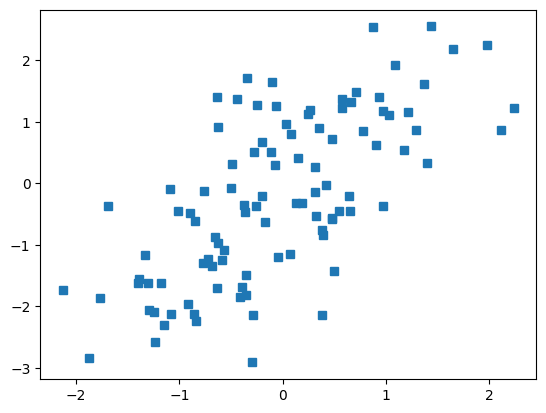

In [13]:
N = 100
x = torch.randn(N, 1)
y = x + torch.randn(N,1)

plt.plot(x, y, 's')
plt.show()

In [14]:
ANNreg = nn.Sequential(
    nn.Linear(1,1),
    nn.ReLU(),
    nn.Linear(1,1)
)

In [17]:
learningRate = .05

lossfun = nn.MSELoss()

optimizer = torch.optim.SGD(ANNreg.parameters(), lr=learningRate)

In [18]:
trainidx = np.random.choice(range(N), 80, replace=False)
trainBool = np.zeros(N, dtype=bool)
trainBool[trainidx] = True

print(x[trainBool].shape)
print(x[~trainBool].shape)

torch.Size([80, 1])
torch.Size([20, 1])


In [19]:
numepochs = 500

for epoch in range(numepochs):

    # Forward Pass
    yHat = ANNreg(x[trainBool])

    # Compute Loss
    loss = lossfun(yHat, y[trainBool])

    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

In [22]:
predYtest = ANNreg(x[~trainBool])
testloss = (predYtest-y[~trainBool]).pow(2).mean()

print(f"Final TRAIN loss: {loss.detach():.2f}")
print(f"Final TEST loss: {testloss.detach():.2f}")

Final TRAIN loss: 1.00
Final TEST loss: 0.86


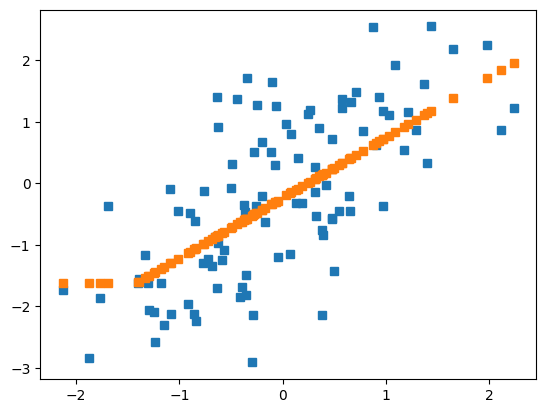

In [28]:
predsY = ANNreg(x)

plt.plot(x, y, 's')
plt.plot(x, predsY.detach(), 's')

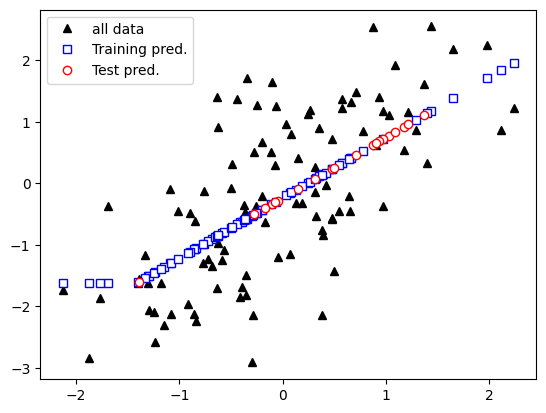

In [30]:
predYtrain = ANNreg(x[trainBool]).detach().numpy()

plt.plot(x, y, 'k^', label="all data")
plt.plot(x[trainBool], predYtrain, 'bs', markerfacecolor='w', label="Training pred.")
plt.plot(x[~trainBool], predYtest.detach(), 'ro', markerfacecolor='w', label='Test pred.')
plt.legend()
plt.show()